Step 1 loading and cleaning data

In [1126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#pd.set_option('display.max_rows', None, 'display.max_columns', None);
db = pd.read_csv('dataset.csv', sep=';')
#r = db.info() #avec cette method on a une petite description de la dataframe, sur le type de donnee des colonnes, le nom des colonnes et autres
#print(r)
#list(db.columns)
#db.dtypes
#print(db.isna())
#print(db.isnull())
stat = db.describe()
#print(stat)
#dupli = db.duplicated()
#db[dupli]
frame = db.drop_duplicates(inplace=True)
dupli = db.duplicated()
assert not dupli.any(), "There is still duplicated info"

Dealing missing value

In [1127]:
date_info = db.describe()
#date_info
#missing = db.isnull().mean() * 100
#print(missing[missing > 0])
comment = ['Cancellation comments', 'Departure delay comments', 'Arrival delay comments']
db.drop(columns=comment, inplace=True)
missing = db.isna().mean() * 100
#print(missing[missing > 0])

CLEANING DATE cloumn

In [1128]:

db["Date"] = pd.to_datetime(db["Date"], errors="coerce")
db['Date'] = db['Date'].dt.strftime('%Y-%m')
db["Date"].ffill(inplace=True)
#db['Date']
#db

/tmp/ipykernel_8587/641454303.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["Date"].ffill(inplace=True)


CLEANING service column

In [1129]:
#frame = pd.isna(db["Service"])
db.loc[db['Service'].str.len() < 9, 'Service'] = "National"
db.loc[db['Service'].str.len() > 9, 'Service'] = "International"
db["Service"].ffill(inplace=True)
#db


/tmp/ipykernel_8587/901070028.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  db["Service"].ffill(inplace=True)


Cleaning int or float columns

In [1130]:
#missing = pd.isnull(db["Average journey time"])
missing = db['Average journey time'].isnull().mean() * 100
med_aver_jr_time = db['Average journey time'].median()
db['Average journey time'] = db['Average journey time'].fillna(med_aver_jr_time)
#db

Number of scheduled trains

In [1131]:
missing = db['Number of scheduled trains'].isnull().mean() * 100
med_sch_trains = db['Number of scheduled trains'].median()
db['Number of scheduled trains'] = db['Number of scheduled trains'].fillna(med_sch_trains)

Number of cancelled trains

In [1132]:
mis = db['Number of cancelled trains'].isnull().mean() * 100
med_cancl_trains = db['Number of cancelled trains'].median()
db['Number of cancelled trains'] = db['Number of cancelled trains'].fillna(med_cancl_trains)

Number of trains delayed at departure

In [1133]:
mis = db['Number of trains delayed at departure'].isnull().mean() * 100
med_dlay_depart = db['Number of trains delayed at departure'].median()
db['Number of trains delayed at departure'] = db['Number of trains delayed at departure'].fillna(med_dlay_depart)
#print(db)

Average delay of late trains at departure

In [1134]:
mis = db['Average delay of late trains at departure'].isnull().mean() * 100
med_dlay_of_late = db['Average delay of late trains at departure'].median()
db['Average delay of late trains at departure'] = db['Average delay of late trains at departure'].fillna(med_dlay_of_late)

Average delay of all trains at departure

In [1135]:
mis = db['Average delay of all trains at departure'].isnull().mean() * 100
med_avr_trains_at_depart = db['Average delay of all trains at departure'].median()
db['Average delay of all trains at departure'] = db['Average delay of all trains at departure'].fillna(med_avr_trains_at_depart)

Number of trains delayed at arrival

In [1136]:
mis = db['Number of trains delayed at arrival'].isnull().mean() * 100
med_trai_dela_arr = db['Number of trains delayed at arrival'].median()
db['Number of trains delayed at arrival'] = db['Number of trains delayed at arrival'].fillna(med_trai_dela_arr)

Average delay of late trains at arrival

In [1137]:
mis = db['Average delay of late trains at arrival'].isnull().mean() * 100
med_avrdelay_arr = db['Average delay of late trains at arrival'].median()
db['Average delay of late trains at arrival'] = db['Average delay of late trains at arrival'].fillna(med_avrdelay_arr)

Average delay of all trains at arrival

In [1138]:
mis = db['Average delay of all trains at arrival'].isnull().mean() * 100
med_avrdelay_all_at_arr = db['Average delay of all trains at arrival'].median()
db['Average delay of all trains at arrival'] = db['Average delay of all trains at arrival'].fillna(med_avrdelay_all_at_arr)

Number of trains delayed > 15min

In [1139]:
mis = db['Number of trains delayed > 15min'].isnull().mean() * 100
med_ = db['Number of trains delayed > 15min'].median()
db['Number of trains delayed > 15min'] = db['Number of trains delayed > 15min'].fillna(med_)

Average delay of trains > 15min (if competing with flights)

In [1140]:
mis = db['Average delay of trains > 15min (if competing with flights)'].isnull().mean() * 100
med = db['Average delay of trains > 15min (if competing with flights)'].median()
db['Average delay of trains > 15min (if competing with flights)'] = db['Average delay of trains > 15min (if competing with flights)'].fillna(med)

Number of trains delayed > 30min

In [1141]:
mis = db['Number of trains delayed > 30min'].isnull().mean() * 100
med_cond = db['Number of trains delayed > 30min'].median()
db['Number of trains delayed > 30min'] = db['Number of trains delayed > 30min'].fillna(med_cond)

Number of trains delayed > 60min

In [1142]:
mis = db['Number of trains delayed > 60min'].isnull().mean() * 100
med_cond60 = db['Number of trains delayed > 60min'].median()
db['Number of trains delayed > 60min'] = db['Number of trains delayed > 60min'].fillna(med_cond60)

Pct delay due to external causes

In [1143]:
mis = db['Pct delay due to external causes'].isnull().mean() * 100
med_pct_causes = db['Pct delay due to external causes'].median()
db['Pct delay due to external causes'] = db['Pct delay due to external causes'].fillna(med_pct_causes)

Pct delay due to infrastructure

In [1144]:
mis = db['Pct delay due to infrastructure'].isnull().mean() * 100
med_pct_infras = db['Pct delay due to infrastructure'].median()
db['Pct delay due to infrastructure'] = db['Pct delay due to infrastructure'].fillna(med_pct_infras)

Pct delay due to traffic management

In [1145]:
mis = db['Pct delay due to traffic management'].isnull().mean() * 100
med_pct_manag = db['Pct delay due to traffic management'].median()
db['Pct delay due to traffic management'] = db['Pct delay due to traffic management'].fillna(med_pct_manag)

Pct delay due to rolling stock

In [1146]:
mis = db['Pct delay due to rolling stock'].isnull().mean() * 100
med_pct_roll = db['Pct delay due to rolling stock'].median()
db['Pct delay due to rolling stock'] = db['Pct delay due to rolling stock'].fillna(med_pct_roll)

Pct delay due to station management and equipment reuse

In [1147]:
mis = db['Pct delay due to station management and equipment reuse'].isnull().mean() * 100
med_pct_reuse = db['Pct delay due to station management and equipment reuse'].median()
db['Pct delay due to station management and equipment reuse'] = db['Pct delay due to station management and equipment reuse'].fillna(med_pct_reuse)

Pct delay due to passenger handling (crowding, disabled persons, connections)

In [1148]:
mis = db['Pct delay due to passenger handling (crowding, disabled persons, connections)'].isnull().mean() * 100
med_delay_hand = db['Pct delay due to passenger handling (crowding, disabled persons, connections)'].median()
db['Pct delay due to passenger handling (crowding, disabled persons, connections)'] = db['Pct delay due to passenger handling (crowding, disabled persons, connections)'].fillna(med_delay_hand)

function to determine outlier

In [1149]:
def find_outlier_IQR(db):
    Q1= db.quantile(0.25)
    Q3=db.quantile(0.75)
    IQR=Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = db[((db < lower) | (db > upper))]
    return outliers

impute outlier

In [1150]:
def impute_outlier(db):
    Q1 = db.quantile(0.25)
    Q3 = db.quantile(0.75)
    IQR = Q3 - Q1
    maxim = db[~(db > (Q3 + 1.5*IQR))].max()
    minim = db[~(db < (Q1 - 1.5*IQR))].min()
    db = np.where(db > maxim,
        db.mean(),
        np.where(
            db < minim,
            db.mean(),
            db
            )
        )
    return db

print info about outlier

In [1151]:
def outlier_info(db, name):
    sns.boxplot(x=db)
    plt.title(name)
    plt.show
    first = find_outlier_IQR(db)
    print("number of outliers: "+ str(len(first)))
    print("max outlier value: "+ str(first.max()))
    print("min outlier value: "+ str(first.min()))
    first

handling Average journey time outlier

number of outliers: 0
max outlier value: nan
min outlier value: nan


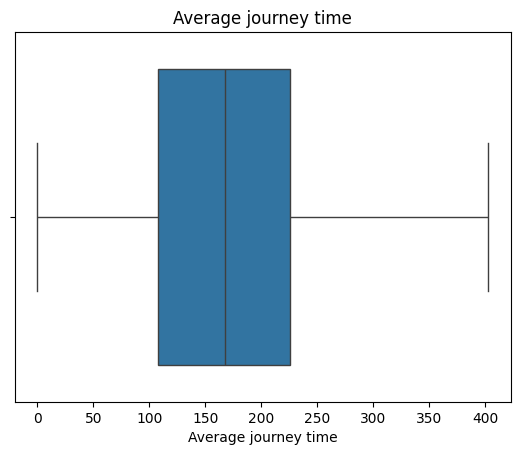

In [1152]:
#outlier_info(db['Average journey time'], "Average journey time")
db['Average journey time'] = impute_outlier(db["Average journey time"])
outlier_info(db['Average journey time'], "Average journey time")
#db.describe()['Average journey time']
#db.info()

handling Number of scheduled trains outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


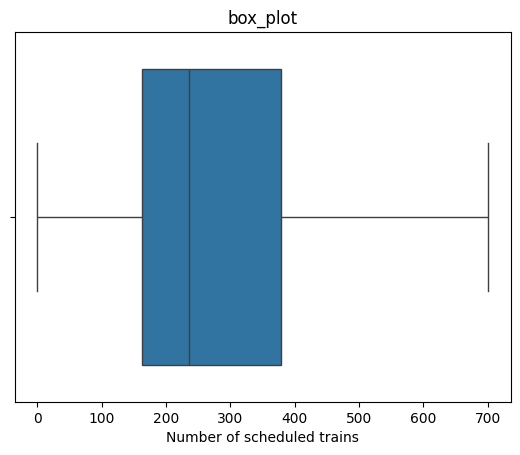

In [1153]:
db['Number of scheduled trains'] = impute_outlier(db['Number of scheduled trains'])
outlier_info(db['Number of scheduled trains'], "box_plot")
#db.describe()['Number of scheduled trains']

handling Number of cancelled trains outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


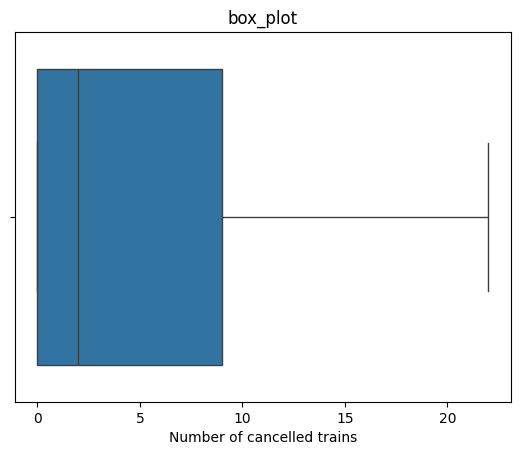

In [1154]:
db['Number of cancelled trains'] = impute_outlier(db["Number of cancelled trains"])
outlier_info(db['Number of cancelled trains'], "box_plot")
#db.describe()['Number of cancelled trains']

Number of trains delayed at departure outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


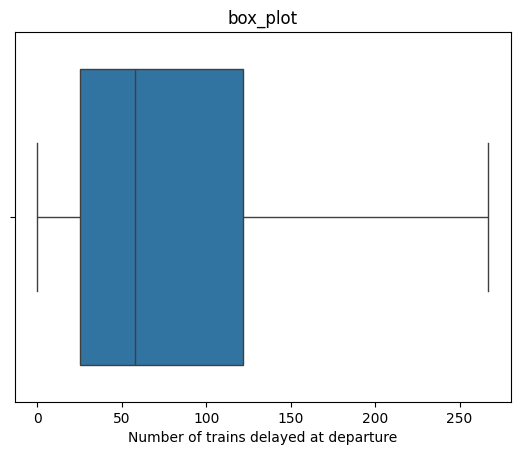

In [1182]:
db['Number of trains delayed at departure'] = impute_outlier(db["Number of trains delayed at departure"])
outlier_info(db['Number of trains delayed at departure'], "box_plot")
#db.describe()['Number of trains delayed at departure']

Average delay of late trains at departure outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


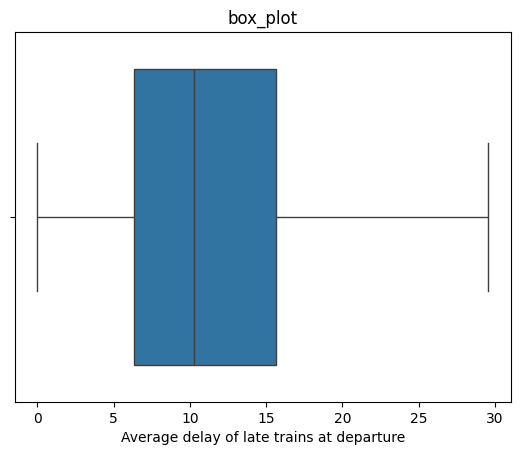

In [1156]:
db['Average delay of late trains at departure'] = impute_outlier(db["Average delay of late trains at departure"])
outlier_info(db['Average delay of late trains at departure'], "box_plot")
#db.describe()['Average delay of late trains at departure']

Average delay of all trains at departure outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


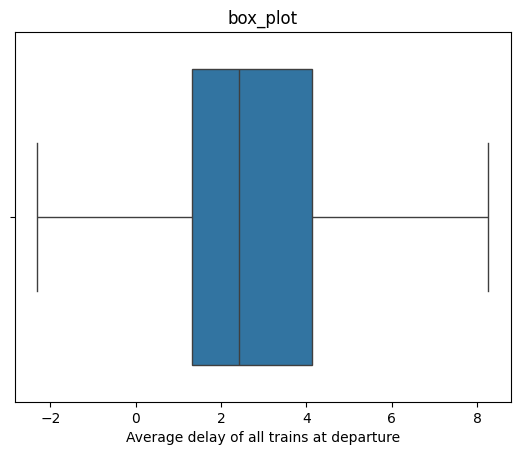

In [1157]:
db['Average delay of all trains at departure'] = impute_outlier(db["Average delay of all trains at departure"])
outlier_info(db['Average delay of all trains at departure'], "box_plot")
#db.describe()['Average delay of all trains at departure']

Number of trains delayed at arrival outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


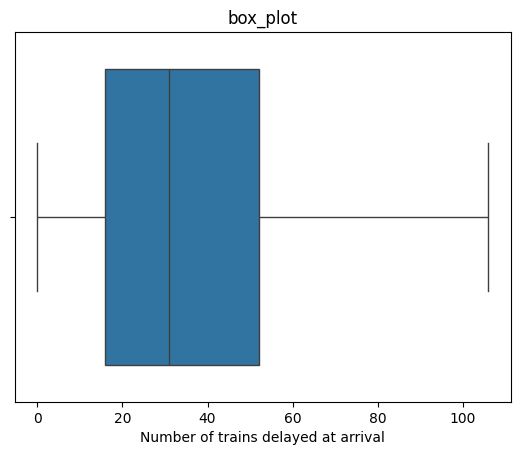

In [1158]:
db['Number of trains delayed at arrival'] = impute_outlier(db["Number of trains delayed at arrival"])
outlier_info(db['Number of trains delayed at arrival'], "box_plot")
#db.describe()['Number of trains delayed at arrival']

Average delay of late trains at arrival outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


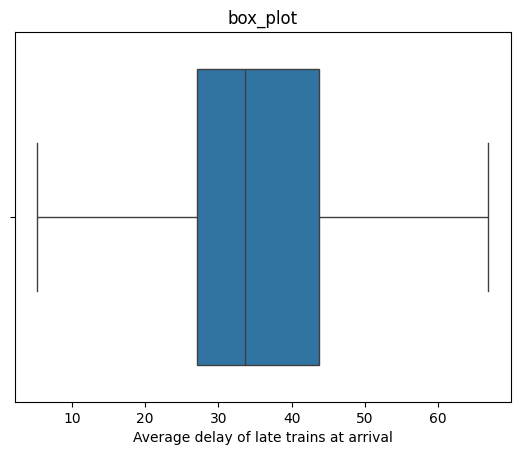

In [1159]:
db['Average delay of late trains at arrival'] = impute_outlier(db["Average delay of late trains at arrival"])
outlier_info(db['Average delay of late trains at arrival'], "box_plot")
#db.describe()['Average delay of late trains at arrival']

Average delay of all trains at arrival

number of outliers: 0
max outlier value: nan
min outlier value: nan


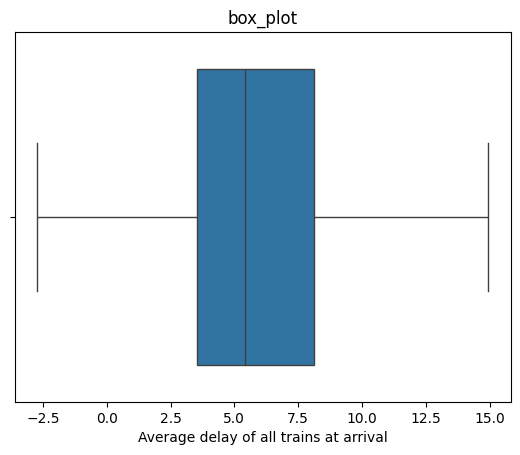

In [1160]:
db['Average delay of all trains at arrival'] = impute_outlier(db["Average delay of all trains at arrival"])
outlier_info(db['Average delay of all trains at arrival'], "box_plot")
#db.describe()['Average delay of all trains at arrival']

Number of trains delayed > 15min outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


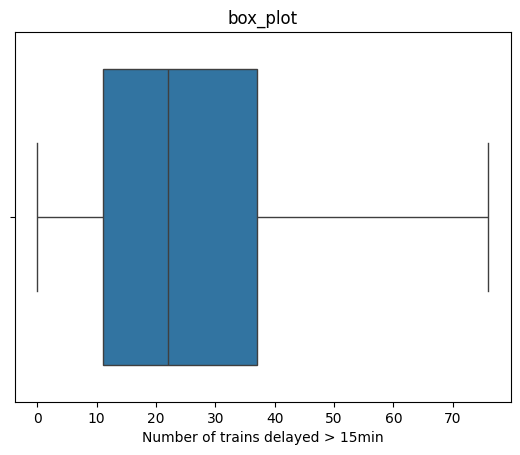

In [1161]:
db['Number of trains delayed > 15min'] = impute_outlier(db["Number of trains delayed > 15min"])
outlier_info(db['Number of trains delayed > 15min'], "box_plot")
#db.describe()['Number of trains delayed > 15min']

Average delay of trains > 15min (if competing with flights) outliers

number of outliers: 169
max outlier value: 3.091055206
min outlier value: 2.080670103


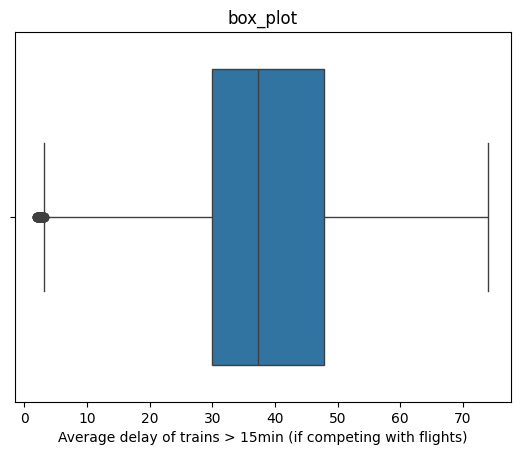

In [1181]:
db['Average delay of trains > 15min (if competing with flights)'] = impute_outlier(db["Average delay of trains > 15min (if competing with flights)"])
outlier_info(db['Average delay of trains > 15min (if competing with flights)'], "box_plot")
#db.describe()['Average delay of trains > 15min (if competing with flights)']

Number of trains delayed > 30min outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


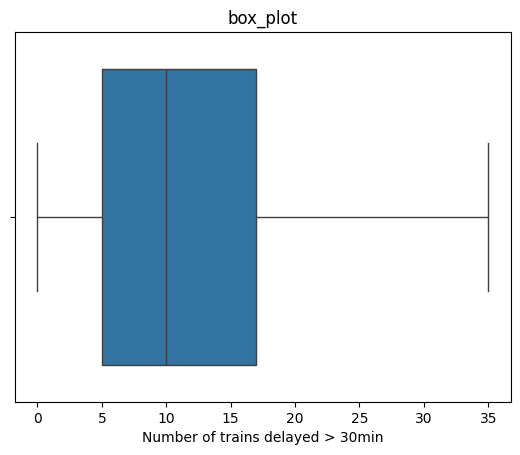

In [1180]:
db['Number of trains delayed > 30min'] = impute_outlier(db["Number of trains delayed > 30min"])
outlier_info(db['Number of trains delayed > 30min'], "box_plot")
#db.describe()['Number of trains delayed > 30min']

Number of trains delayed > 60min outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


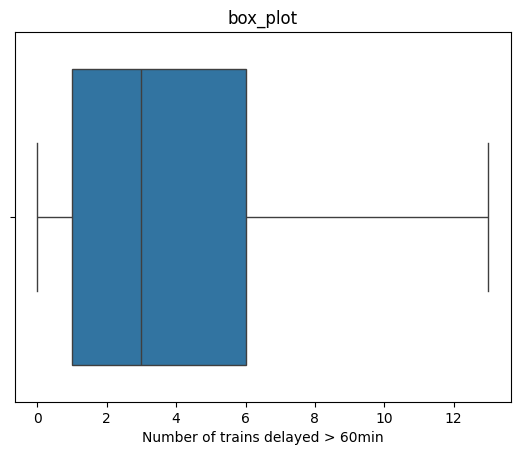

In [1179]:
db['Number of trains delayed > 60min'] = impute_outlier(db["Number of trains delayed > 60min"])
outlier_info(db['Number of trains delayed > 60min'], "box_plot")
#db.describe()['Number of trains delayed > 60min']

Pct delay due to external causes outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


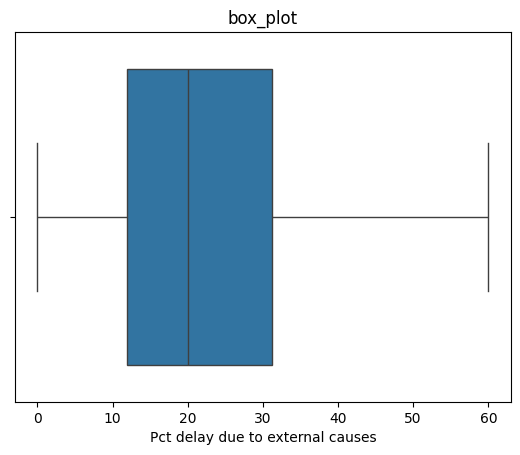

In [1178]:
db['Pct delay due to external causes'] = impute_outlier(db["Pct delay due to external causes"])
outlier_info(db['Pct delay due to external causes'], "box_plot")
#db.describe()['Pct delay due to external causes']

Pct delay due to infrastructure outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


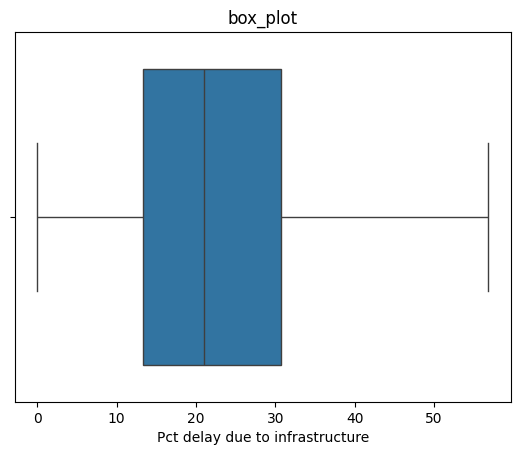

In [1166]:
db['Pct delay due to infrastructure'] = impute_outlier(db["Pct delay due to infrastructure"])
outlier_info(db['Pct delay due to infrastructure'], "box_plot")
#db.describe()['Pct delay due to infrastructure']

Pct delay due to traffic management outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


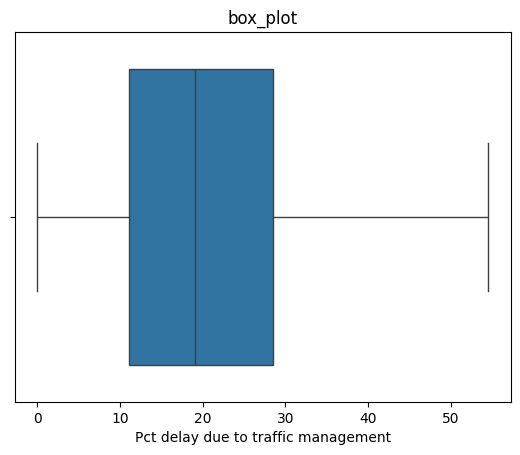

In [1167]:
db['Pct delay due to traffic management'] = impute_outlier(db["Pct delay due to traffic management"])
outlier_info(db['Pct delay due to traffic management'], "box_plot")
#db.describe()['Pct delay due to traffic management']

Pct delay due to rolling stock outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


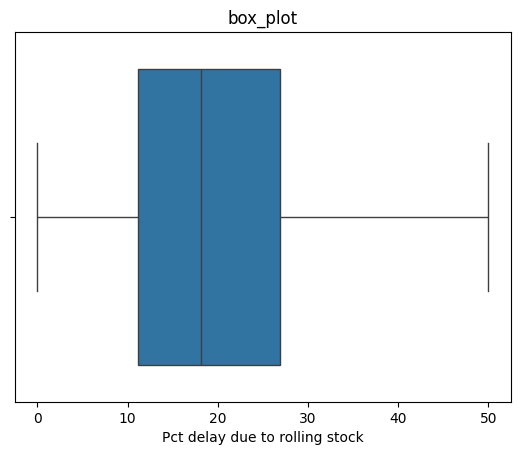

In [1168]:
db['Pct delay due to rolling stock'] = impute_outlier(db["Pct delay due to rolling stock"])
outlier_info(db['Pct delay due to rolling stock'], "box_plot")
#db.describe()['Pct delay due to rolling stock']

Pct delay due to station management and equipment reuse outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


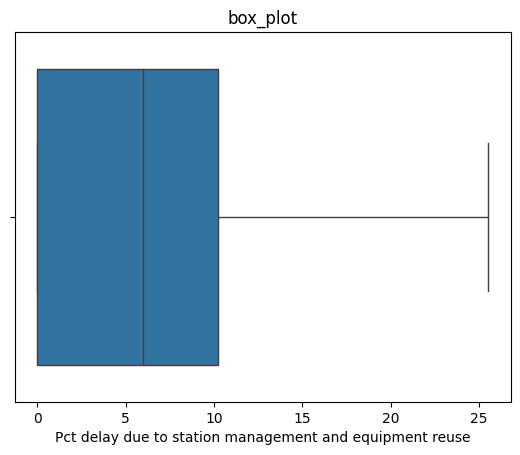

In [1177]:
db['Pct delay due to station management and equipment reuse'] = impute_outlier(db["Pct delay due to station management and equipment reuse"])
outlier_info(db['Pct delay due to station management and equipment reuse'], "box_plot")
#db.describe()['Pct delay due to station management and equipment reuse']

Pct delay due to passenger handling (crowding, disabled persons, connections) outliers

number of outliers: 0
max outlier value: nan
min outlier value: nan


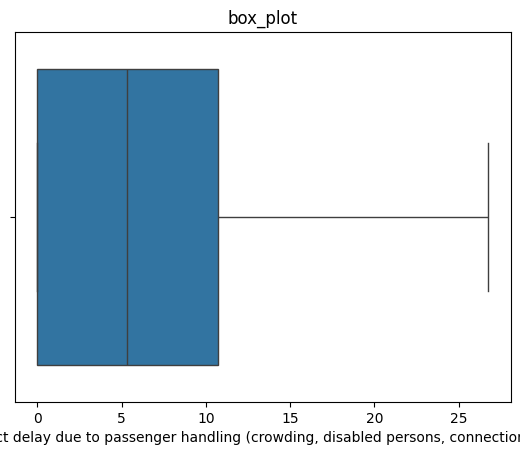

In [1176]:
db['Pct delay due to passenger handling (crowding, disabled persons, connections)'] = impute_outlier(db["Pct delay due to passenger handling (crowding, disabled persons, connections)"])
outlier_info(db['Pct delay due to passenger handling (crowding, disabled persons, connections)'], "box_plot")
#db.describe()['Pct delay due to passenger handling (crowding, disabled persons, connections)']

cleaning departure and arrival colonnes

In [1171]:
db.info()
#db

<class 'pandas.core.frame.DataFrame'>
Index: 10662 entries, 0 to 10839
Data columns (total 23 columns):
 #   Column                                                                         Non-Null Count  Dtype  
---  ------                                                                         --------------  -----  
 0   Date                                                                           10662 non-null  object 
 1   Service                                                                        10662 non-null  object 
 2   Departure station                                                              10131 non-null  object 
 3   Arrival station                                                                10126 non-null  object 
 4   Average journey time                                                           10662 non-null  float64
 5   Number of scheduled trains                                                     10662 non-null  float64
 6   Number of cancelled trains 

0 Date ==> object to daatetime64;
1 servie ==> object;
2 object;
3 object;
4 float;
5 int;
6 int;
7 int;
8 tjrs float;
9 tjrs float;
10 int;
11 tjrs float
12 tjrs float;
13 int;
14 tjrs float;
15 int;
16 int;
17 tjrs float;
18 a 22 float;

colonnes a convertir le type

In [1172]:
dictionary = {'Number of scheduled trains': int, 'Number of cancelled trains': int, 'Number of trains delayed at departure': int, 'Number of trains delayed at arrival': int, 'Number of trains delayed > 15min': int, 'Number of trains delayed > 30min': int, 'Number of trains delayed > 60min': int}
db = db.astype(dictionary)
db["Date"] = db["Date"].astype('datetime64[ns]')
#print(db.dtypes)
#db

Application de la feature engineering qui consiste a creer d'autres colonnes

In [1173]:
def delay_category(x):
    if x <= 5:
        return "On time"
    elif x <= 15:
        return "Slight delay"
    elif x <= 30:
        return "Moderate delay"
    else:
        return "Heavy delay"

In [1174]:
db["Month"] = db["Date"].dt.month
db["Day of Week"] = db["Date"].dt.day_name()
db["YearMonth"] = db["Date"].dt.to_period("M")
db["is_weekend"] = db["Date"].dt.dayofweek >= 5
db["is_delayed"] = ((db["Average delay of all trains at departure"] > 5) | (db["Average delay of all trains at arrival"] > 5)).astype(int)
db["delay_category"] = db["Average delay of all trains at departure"].apply(delay_category)

Save the clean dataframe

In [1184]:
df_export = db.copy()
df_export["Date"] = df_export["Date"].dt.strftime("%Y-%m")
df_export.to_csv('cleaned_dataset.csv', index=False)